# Mouse embryogenesis

In this tutorial, we'll use Pycea to explore fate-restriction dynamics in mouse embryo lineage tracing data from [Colgan et al. 2026](https://www.biorxiv.org/content/10.64898/2026.05.07.722278v3). 

This study uses PEtracer to reconstruct lineage trees for 16 embryos staged at half-day intervals from E7.5 to E10.0. These trees resolve ~75% of the cell divisions and have accurate molecular clock-based branch length estimates. The data can be explored interactively at [mela.wi.mit.edu](https://mela.wi.mit.edu/).

In [1]:
import pycea as py
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (6, 6)

The embryo lineage trees and metadata can be easily loaded using {func}`pycea.datasets.colgan26()`. If you want to also analyze the expression data you can download the complete H5TD files from [zenodo](https://doi.org/10.5281/zenodo.19892784) and load them with {func}`treedata.read_h5td()`.

For this tutorial, we will focus on E9.5 replicate 1 (E9.5-R1) with 382,254 cells. The three clone trees (C1, C2, and C3) represent three seeding cells injected into the host morula at the start of the experiment, which then proliferated and differentiated into the embryo.

In [ ]:
tdata = py.datasets.colgan26(embryos="E9.5-R1")
tdata

TreeData object with n_obs × n_vars = 382254 × 0
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'cluster', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'cell_subtype_colors', 'cell_type_colors', 'default_depth', 'embryo_colors', 'germ_layer_colors', 'lineage_colors', 'phase_colors', 'stage_colors', 'type_colors'
    obsm: 'X_umap'
    obst: 'E9.5-R1-C1', 'E9.5-R1-C2', 'E9.5-R1-C3'

## Cell annotation

The cells are annotated at four levels of granularity: germ layer, lineage, cell type, and cell subtypes. Let's plot the UMAP colored by germ layer and lineage using {func}`scanpy.pl.umap()`.

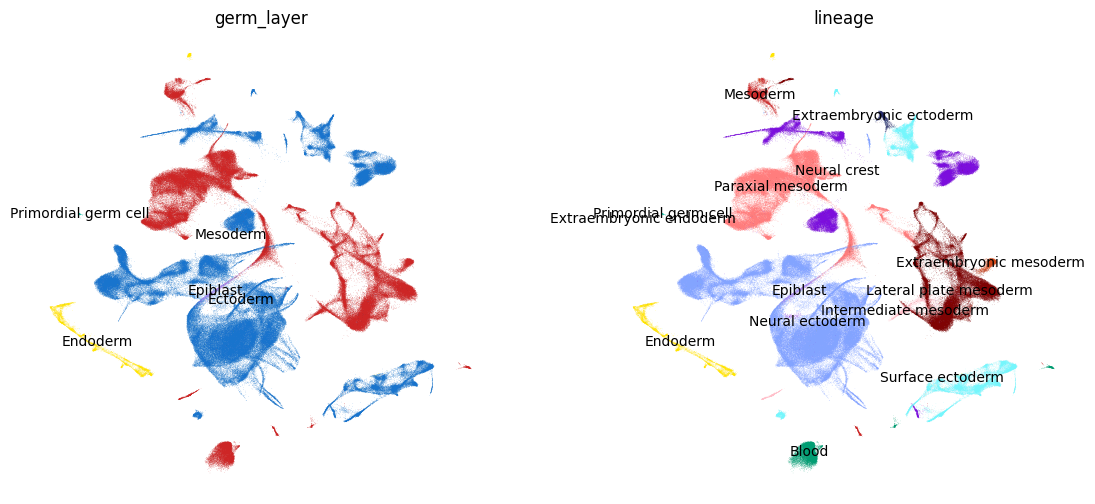

In [4]:
sc.pl.umap(tdata, color=["germ_layer", "lineage"], legend_loc="on data", frameon=False, legend_fontweight="regular");

Now we can use {func}`pycea.pl.tree()` to visualize the lineage tree with the same color scheme. The three trees are rooted at the seeding cells and the branch lengths indicate the approximate time in days between cell divisions. Multifurcations in the tree represent unresolved cell divisions.

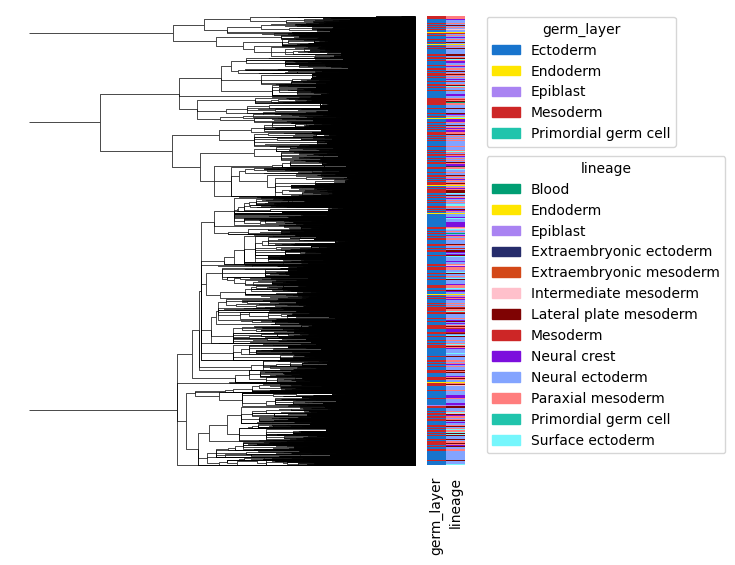

In [5]:
py.pl.tree(tdata, keys=["germ_layer", "lineage"]);

Let's zoom in on part of the tree by subsetting the `tdata` object to indices 10,000-15,000. Now we can clearly see how the germ layers organize into distinct clades with each of these clades enriched for a specific lineage such as paraxial and lateral plate mesoderm.

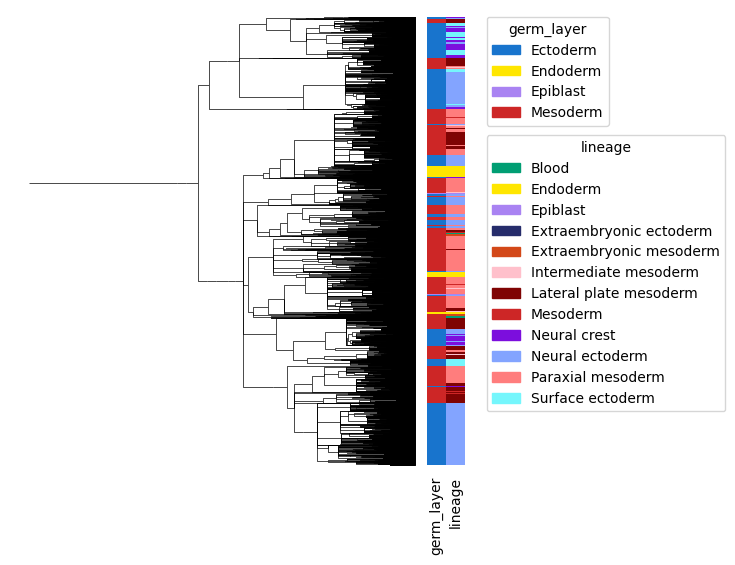

In [6]:
py.pl.tree(tdata[10000:15000], keys=["germ_layer", "lineage"]);

## Neighborhood analysis

An interesting exception is the neural crest lineage which is intermixed with neural and surface ectoderm. Let's start exploring neural crest specification by focusing on a single neural crest cell (E9.5-R1-T10-AGCTTAGTCTGGCTGG-1). We can use {func}`pycea.tl.tree_neighbors()` to identify the 50 nearest neighbors of this cell in the lineage tree.

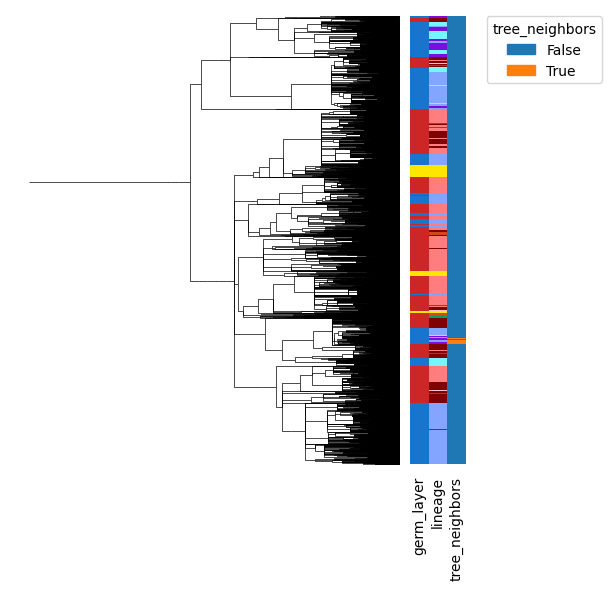

In [7]:
py.tl.tree_neighbors(tdata, obs="E9.5-R1-T10-AGCTTAGTCTGGCTGG-1", n_neighbors=50)
py.pl.tree(tdata[10000:15000], keys=["germ_layer", "lineage"], legend=False)
py.pl.annotation(tdata[10000:15000], keys=["tree_neighbors"], gap=0);

All of these neighbors are either neural crest or neural ectoderm.

In [8]:
tdata.obs.query("tree_neighbors")["lineage"].value_counts().head(5)

lineage
Neural crest       31
Neural ectoderm    19
Blood               0
Endoderm            0
Epiblast            0
Name: count, dtype: int64

Alternatively, we can use {func}`pycea.tl.tree_distance()` to compute the lowest common ancestor (LCA) between this cell and all other cells in the tree.

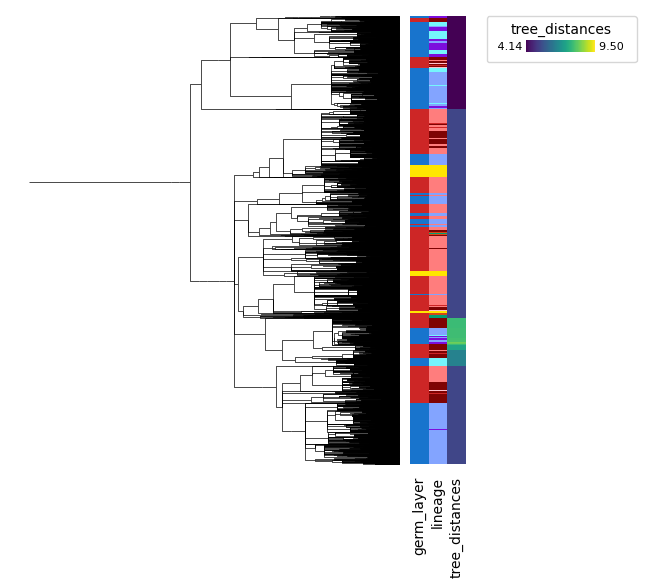

In [9]:
py.tl.tree_distance(tdata, obs="E9.5-R1-T10-AGCTTAGTCTGGCTGG-1", metric="lca")
py.pl.tree(tdata[10000:15000], keys=["germ_layer", "lineage"], legend=False)
py.pl.annotation(tdata[10000:15000], keys=["tree_distances"], gap=0);

This highlights a set of neural ectoderm and lateral plate mesoderm cells that are closely related to this neural crest cell. But this is just one of thousands of neural crest cells so we can't conclude that neural crest cells are always closely related to the lateral plate mesoderm. To get a more complete picture we need a metric that takes into account all of the neural crest cells.

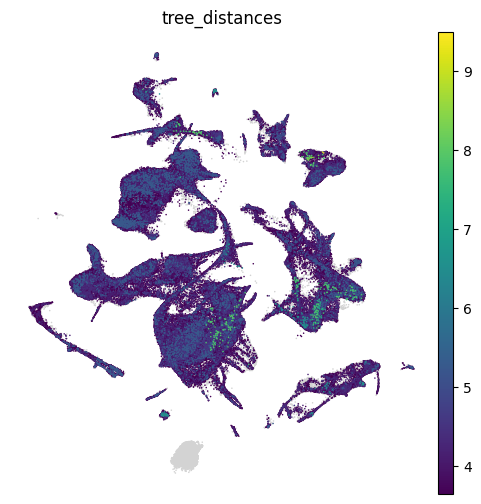

In [10]:
sc.pl.umap(tdata, color="tree_distances", frameon=False, s=5);

## Ancestral linkage

{func}`pycea.tl.ancestral_linkage()` calculates how closely related each cell is to a target set (e.g. neural crest cells) based on the time of its most recent common ancestor with the nearest target cell. Because tree structure and target size affect this value, it is normalized by subtracting the mean after randomly permuting the labels. A score of 0 is the chance expectation, and higher scores indicate more closely related than chance.

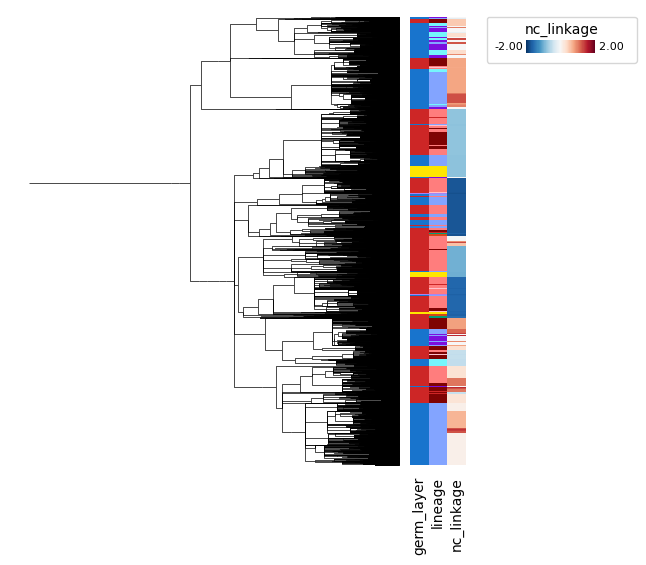

In [11]:
py.tl.ancestral_linkage(tdata, groupby="lineage", target="Neural crest", key_added="nc")
py.pl.tree(tdata[10000:15000], keys=["germ_layer", "lineage"], legend=False)
py.pl.annotation(tdata[10000:15000], keys=["nc_linkage"], gap=0, cmap="RdBu_r", vmin=-2, vmax=2);

We can then color the UMAP by the neural crest ancestral linkage. Red cells are more closely related to the neural crest than expected by chance and blue cells are less closely related.

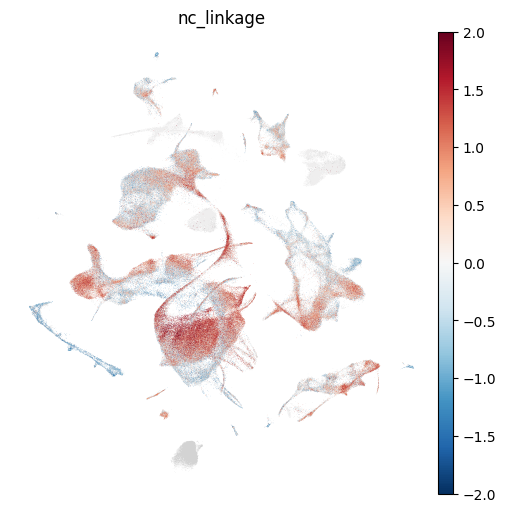

In [12]:
sc.pl.umap(tdata, color="nc_linkage", vmax=2, vmin=-2, cmap="RdBu_r", frameon=False);

At the lineage level, the neural crest is most closely related to the epiblast, followed by the intermediate mesoderm, consistent with the similar positions of these lineages along the mediolateral axis.

In [13]:
tdata.obs.groupby("lineage").agg({"nc_linkage": "mean"}).sort_values("nc_linkage", ascending=False).head(5)

,nc_linkage
lineage,
Epiblast,0.312208
Intermediate mesoderm,0.235015
Surface ectoderm,0.179463
Neural ectoderm,0.176770
Neural crest,0.000000


At the cell type level, the neural crest is most closely related to the roof plate, consistent with its origin from the dorsal neural tube.

In [14]:
tdata.obs.groupby("cell_type").agg({"nc_linkage": "mean"}).sort_values("nc_linkage", ascending=False).head(5)

,nc_linkage
cell_type,
Roof plate,1.045280
Spinal cord (thoracic),0.538721
Spinal cord (lumbar),0.533980
Trigeminal placode,0.505107
Olfactory sensory neuron,0.446973


## Pairwise ancestral linkage

{func}`pycea.tl.ancestral_linkage()` can also compute the linkage between every pair of lineages or cell types. Set the `groupby` parameter to the column of interest and leave `target` as `None`. For each pair of categories, every cell in the first (source) category is scored by its most recent common ancestor with the nearest cell in the second (target) category, and these scores are averaged over the source cells. Because the score is directional, the matrix is asymmetric, so by default the two directions are averaged.

In [15]:
py.tl.ancestral_linkage(tdata, groupby="lineage")

The resulting matrix can be visualized using {func}`pycea.pl.ancestral_linkage()`.

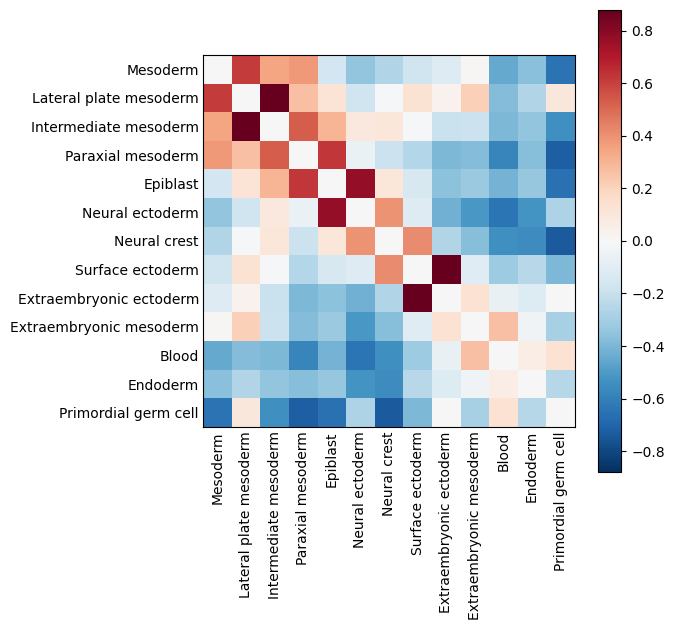

In [16]:
py.pl.ancestral_linkage(tdata);

## Fate bias

Now let's explore how fates are specified over time. We can use {func}`pycea.tl.ancestral_states()` to compute the fraction of each internal node's descendant cells that are neural crest.

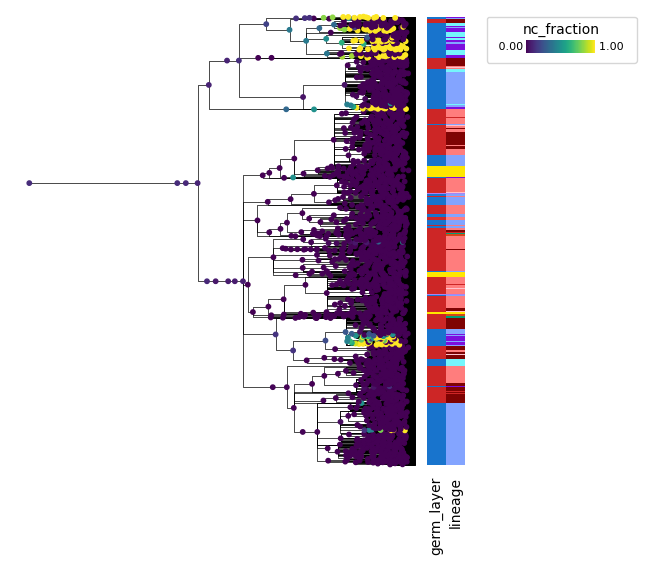

In [17]:
tdata.obs["is_nc"] = tdata.obs["lineage"] == "Neural crest"
py.tl.ancestral_states(tdata, "is_nc", method="mean", keys_added="nc_fraction")
py.pl.tree(tdata[10000:15000], keys=["germ_layer", "lineage"], legend=False)
py.pl.nodes(tdata[10000:15000], color="nc_fraction");

We can then use {func}`pycea.get.node_df()` get the neural crest fraction for all neural crest ancestors and plot the mean fraction over time. This shows that neural crest specification occurs around E8.0.

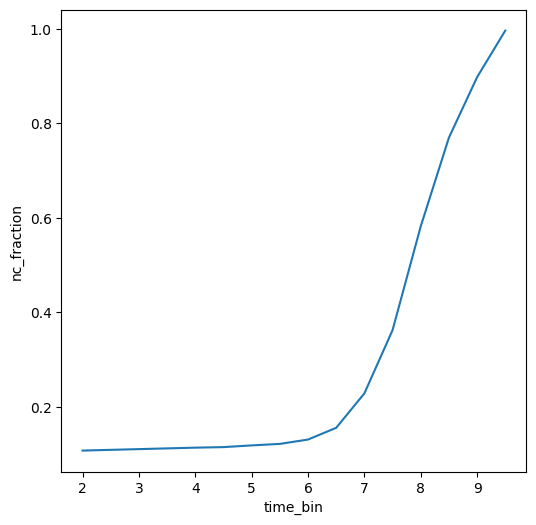

In [18]:
nc_ancestors = py.get.node_df(tdata[tdata.obs.lineage == "Neural crest"])
edges = np.arange(0, 10, 0.5)
nc_ancestors["time_bin"] = pd.cut(nc_ancestors["time"], bins=edges, labels=edges[1:])
mean_nc_fraction = nc_ancestors.groupby("time_bin").agg({"nc_fraction": "mean"}).reset_index()
sns.lineplot(mean_nc_fraction, x="time_bin", y="nc_fraction");

We can repeat this analysis across the other lineages revealing that endoderm tends to be specified first and intermediate mesoderm last.

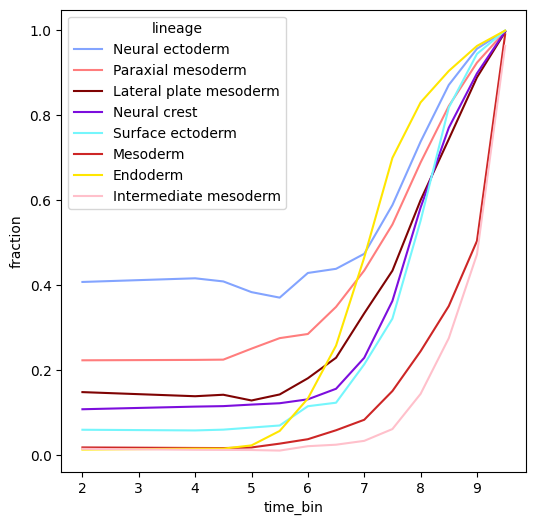

In [19]:
results = []
for lineage in tdata.obs.query("tree.notnull()").lineage.value_counts().head(8).index:
    tdata.obs["is_lineage"] = tdata.obs.lineage == lineage
    py.tl.ancestral_states(tdata, "is_lineage", method="mean", keys_added="fraction")
    lineage_ancestors = py.get.node_df(tdata[tdata.obs.lineage == lineage])
    lineage_ancestors["time_bin"] = pd.cut(lineage_ancestors["time"], bins=edges, labels=edges[1:])
    lineage_mean = lineage_ancestors.groupby("time_bin", observed=True).agg({"fraction": "mean"}).reset_index()
    results.append(lineage_mean.assign(lineage=lineage))
lineage_palette = py.get.palette(tdata, "lineage")
sns.lineplot(data=pd.concat(results), x="time_bin", y="fraction", hue="lineage", palette=lineage_palette);